In [1]:
# --- Imports -----------------------------------------------------------------
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from libpysal.weights import DistanceBand, lag_spatial
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import seaborn as sns
# --- Load shapefile ----------------------------------------------------------
gdf = gpd.read_file('../Data/Shapefiles/20240627_APES FINAL_metric.shp')

# --- Filter & basic cleaning -------------------------------------------------
# remove ZIKV, drop empty geometries
gdf = gdf.loc[gdf['RcrdTyp'] != 'ZIKV'].copy()
gdf = gdf.loc[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()

# columns
id_cols = ["NUTS_NA", "NUTS_CO"]
predictor_cols = [
    "Forest", "Shrub", "Urban", "Crop", "Water", "Other",
    "Mn_P_Wn",   # Mean_P_Winter
    "Mx_WD_W",   # Max_WD_Winter
    "Mx_DD_W",   # Max_DD_Winter
    "Mn_T_Sp",   # Mean_T_Spring
    "Mx_DD_Sp",  # Max_DD_Spring
    "Mn_T_Sm",   # Mean_T_Summer  (included to match your R comment)
    "Mx_WD_A",   # Max_WD_Autumn
    "Mx_DD_A",   # Max_DD_Autumn
    "gdp", "pop_dns"
]
response_col = "incidnc"

In [2]:
# keep only available columns (plus geometry and IDs)
keep = [c for c in (id_cols + predictor_cols + [response_col, "geometry"]) if c in gdf.columns]
gdf = gdf[keep].copy()

# --- Aggregate to NUTS level -------------------------------------------------
# incidence = sum; all predictors = mean (like your R summarise)
agg_dict = {response_col: "sum"}
agg_dict.update({c: "mean" for c in predictor_cols if c in gdf.columns})

fin_eu3 = (
    gdf
    .groupby(id_cols, as_index=False)
    .agg(agg_dict)
)

# restore a representative geometry per NUTS (assumes unique geometry per NUTS)
geom_first = (
    gdf[id_cols + ["geometry"]]
    .drop_duplicates(id_cols)
)
fin_eu3 = fin_eu3.merge(geom_first, on=id_cols, how="left")
fin_eu3 = gpd.GeoDataFrame(fin_eu3, geometry="geometry", crs=gdf.crs)

# drop rows with any NA in variables we need
needed = [response_col] + [c for c in predictor_cols if c in fin_eu3.columns]
fin_eu3 = fin_eu3.dropna(subset=needed).copy()

In [3]:
# --- Project to metric CRS and compute centroids -----------------------------
# Use a metric CRS for distances (UTM zone 33N as in your R code)
fin_eu3 = fin_eu3.to_crs(32633)
centroids = fin_eu3.geometry.centroid  # in meters now
coords = np.c_[centroids.x, centroids.y]

In [4]:
# Replace StandardScaler with manual z-score using ddof=1
num_cols = fin_eu3.select_dtypes(include="number").columns.tolist()

fin_eu3_std = fin_eu3.copy()
for c in num_cols:
    s = fin_eu3[c]
    fin_eu3_std[c] = (s - s.mean()) / s.std(ddof=1)   # R's scale()

In [31]:
# --- Spatial weights (binary distance band, row-standardized) ----------------
max_distance = 175000  # 150 km
# coords already from centroids in metric CRS
eps = 1e-9  # make the threshold inclusive like R
w = DistanceBand.from_array(coords, threshold=max_distance + eps, binary=True, silence_warnings=True)

# Do NOT row-standardize here; keep it binary like style="B"
# w.transform = "R"  # <-- leave this OUT

W_matrix = w.full()[0]          # dense 0/1 matrix
y = fin_eu3_std["incidnc"].to_numpy()  # already scaled like R if you scaled it
Wy = W_matrix.dot(y)            # binary SUM of neighbors
fin_eu3_std["Y_weighted"] = Wy

In [32]:
y = fin_eu3_std["Y_weighted"].to_numpy().reshape(-1, 1)
#y =  fin_eu3['incidnc'].to_numpy().reshape(-1, 1)
X = fin_eu3_std[predictor_cols].to_numpy()

# coords from centroids (metric CRS)
bw = Sel_BW(coords, y, X, kernel='gaussian', fixed=False).search()
gwr_res = GWR(coords, y, X, bw, kernel='gaussian', fixed=False, constant=True).fit()

In [34]:
candidates = [
    ('bisquare', False),
    ('gaussian', False),
    ('exponential', False)
]

results = []
for kernel, fixed in candidates:
    bw = Sel_BW(coords, y, X, kernel=kernel, fixed=fixed).search()
    res = GWR(coords, y, X, bw, kernel=kernel, fixed=fixed, constant=True).fit()
    results.append((kernel, fixed, bw, res.aicc, float(res.localR2.mean())))

for k, f, bw, aicc, r2 in results:
    print(f"{k:11s} {'fixed' if f else 'adaptive'} | bw={bw} | AICc={aicc:.1f} | mean localR2={r2:.3f}")

LinAlgError: Matrix is singular.

In [35]:
for k, f, bw, aicc, r2 in results:
    print(f"{k:11s} {'fixed' if f else 'adaptive'} | bw={bw} | AICc={aicc:.1f} | mean localR2={r2:.3f}")

bisquare    adaptive | bw=86.0 | AICc=7243.3 | mean localR2=0.836
gaussian    adaptive | bw=75.0 | AICc=7360.6 | mean localR2=0.805
exponential adaptive | bw=75.0 | AICc=7289.3 | mean localR2=0.839


Q:\UserTemp\massaro\AppData\Local\Temp\260\ipykernel_111464\747315676.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fin_eu3_std['gwr_localR2'], hist = False, kde = True,kde_kws = {'shade': True, 'linewidth': 3});
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\seaborn\distributions.py:2496: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


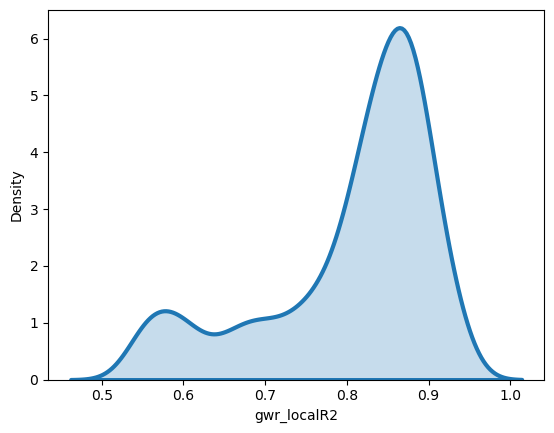

In [33]:
fin_eu3_std["gwr_localR2"] = gwr_res.localR2
fin_eu3_std["gwr_aicc"] = gwr_res.aicc
sns.distplot(fin_eu3_std['gwr_localR2'], hist = False, kde = True,kde_kws = {'shade': True, 'linewidth': 3});

In [29]:
gdf_plot = fin_eu3_std.to_crs('EPSG:4326')

In [19]:
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# --- Projection ---
proj = ccrs.PlateCarree()  # simple lat/lon projection
url = "../Data/Shapefiles/world-administrative-boundaries.zip"
world = gpd.read_file(url)

In [20]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


bins = [0, 0.05, 0.10, 0.50, 0.90, 0.92, 0.96, 0.99, 1.00]
labels = [
    "0 < R² ≤ 0.05",
    "0.05 < R² ≤ 0.10",
    "0.10 < R² ≤ 0.50",
    "0.50 < R² ≤ 0.90",
    "0.90 < R² ≤ 0.92",
    "0.92 < R² ≤ 0.96",
    "0.96 < R² ≤ 0.99",
    "0.99 < R² ≤ 1.00",
]

# Hand-picked colors roughly matching your palette (red→yellow→greens→blues→navy)
colors = [
    "#a50026",  # deep red
    "#f46d43",  # orange
    "#fee08b",  # yellow
    "#abdda4",  # light green
    "#66c2a5",  # green-cyan
    "#3288bd",  # medium blue
    "#225ea8",  # dark blue
    "#081d58",  # navy
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

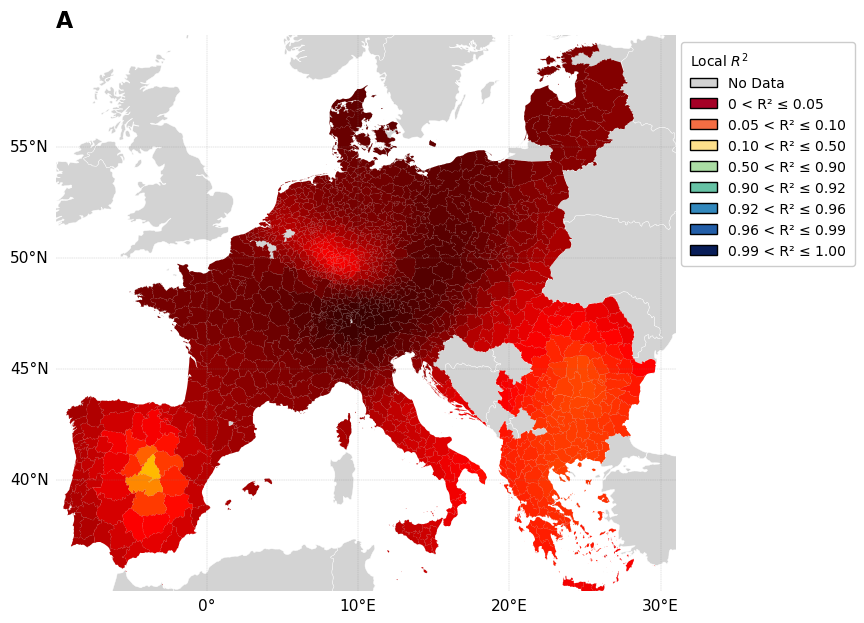

In [30]:
import pylab as plt
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})

world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0)
gdf_plot.plot(ax=ax, column='gwr_localR2', cmap='hot_r', vmin=0, vmax=1)
# --- Style ---
ax.set_axis_off()
ax.set_xlim(-10, 31)
ax.set_ylim(35, 60)

# --- Add Cartopy gridlines ---
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Custom legend matching bins
handles = [Patch(facecolor=colors[i], edgecolor="black", label=labels[i]) for i in range(len(labels))]
# Add "No Data" patch
handles = [Patch(facecolor="lightgrey", edgecolor="black", label="No Data")] + handles

ax.set_axis_off()
ax.set_title("A", loc="left", fontsize=16, fontweight="bold")

leg = ax.legend(
    handles=handles,
    title="Local $R^2$",
    loc="upper right",
    bbox_to_anchor=(1.3, 1),
    frameon=True,
    framealpha=1.0,
    borderpad=0.6,
)
leg._legend_box.align = "left"

(array([ 67.,  59.,  23.,  35.,  65.,  61., 150., 250., 315., 109.]),
 array([0.52625633, 0.56707643, 0.60789653, 0.64871663, 0.68953673,
        0.73035683, 0.77117693, 0.81199704, 0.85281714, 0.89363724,
        0.93445734]),
 <BarContainer object of 10 artists>)

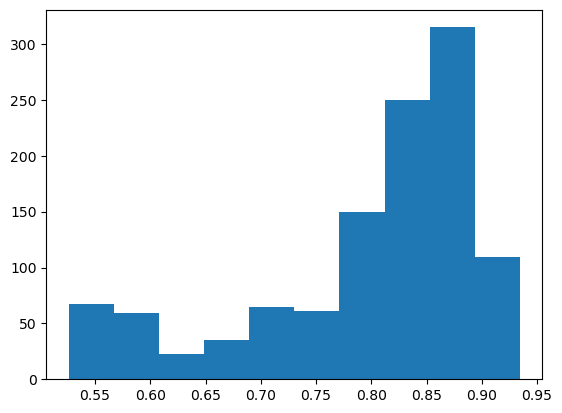

In [22]:
plt.hist(gdf_plot['gwr_localR2'])

In [ ]:
import seaborn as sns

In [ ]:
sns.distplot(gdf_plot['gwr_localR2'], hist = False, kde = True,kde_kws = {'shade': True, 'linewidth': 3});

In [23]:
gdf_plot['gwr_localR2'].min()

0.526256329105466